In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ROOT_DIR = Path.cwd().parent

data_path = ROOT_DIR / "data"

In [3]:
dv = pd.read_csv(data_path / "daily_volatility.csv")
rfqs = pd.read_csv(data_path / "rfqs.csv")

In [4]:
dv.head(10)

,date,underlying,realized_vol_63d
0,2014-04-01,KYBR,0.194111
1,2014-04-02,KYBR,0.186989
2,2014-04-03,KYBR,0.188895
3,2014-04-04,KYBR,0.187141
4,2014-04-07,KYBR,0.195557
5,2014-04-08,KYBR,0.196198
6,2014-04-09,KYBR,0.192145
7,2014-04-10,KYBR,0.189903
8,2014-04-11,KYBR,0.186555
9,2014-04-14,KYBR,0.189063


In [5]:
display(dv.info())
display(dv.describe())

<class 'pandas.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              44744 non-null  str    
 1   underlying        44744 non-null  str    
 2   realized_vol_63d  44744 non-null  float64
dtypes: float64(1), str(2)
memory usage: 1.0 MB


None

,realized_vol_63d
count,44744.000000
mean,0.370341
std,0.212618
min,0.089770
25%,0.234484
50%,0.322039
75%,0.451927
max,1.623879


La volatilidad es una métrica estrictamente positiva, `realized_vol_63d` cumple la cota esperada.

In [6]:
print(f"Pares (date, underlying) duplicados: {dv.duplicated(subset=['date', 'underlying']).sum()}")
print(f"Subyacentes unicos: {dv['underlying'].unique()}")

Pares (date, underlying) duplicados: 0
Subyacentes unicos: <StringArray>
['KYBR', 'CORL', 'MNDO', 'HTTX', 'TECH', 'SITH', 'JEDI', 'BSKR', 'POBK',
 'NABO', 'REBL', 'WOOK', 'CLNE',  'DRC']
Length: 14, dtype: str


In [7]:
tickers_rfqs = set('|'.join(rfqs['underlyings']).split('|'))
tickers_dv = set(dv['underlying'].unique())

print("En rfqs pero no en dv:", tickers_rfqs - tickers_dv)
print("En dv pero no en rfqs:", tickers_dv - tickers_rfqs)

En rfqs pero no en dv: set()
En dv pero no en rfqs: set()


No hay ningún subyacente no usado en ninguna RFQ, pero lo más importante, no hay subyacentes entre los RFQs para los que no tengamos infromación.

In [8]:
dv['date'] = pd.to_datetime(dv['date'])
dv['date'].dt.dayofweek.value_counts().sort_index()

date
0    8946
1    8960
2    8946
3    8946
4    8946
Name: count, dtype: int64

No hay datos en fin de semana (5=sabado, 6=domingo), como es de esperar para un panel de mercado.

In [9]:
cobertura = dv.groupby('underlying')['date'].agg(['min', 'max', 'count'])
cobertura

,min,max,count
underlying,,,
BSKR,2014-04-01,2026-06-30,3196
CLNE,2014-04-01,2026-06-30,3196
CORL,2014-04-01,2026-06-30,3196
DRC,2014-04-01,2026-06-30,3196
HTTX,2014-04-01,2026-06-30,3196
JEDI,2014-04-01,2026-06-30,3196
KYBR,2014-04-01,2026-06-30,3196
MNDO,2014-04-01,2026-06-30,3196
NABO,2014-04-01,2026-06-30,3196


In [10]:
cobertura['dias_habiles_esperados'] = cobertura.apply(
    lambda row: len(pd.bdate_range(row['min'], row['max'])), axis=1
)
cobertura['huecos'] = cobertura['dias_habiles_esperados'] - cobertura['count']
cobertura.sort_values('huecos', ascending=False)

,min,max,count,dias_habiles_esperados,huecos
underlying,,,,,
BSKR,2014-04-01,2026-06-30,3196,3196,0
CLNE,2014-04-01,2026-06-30,3196,3196,0
CORL,2014-04-01,2026-06-30,3196,3196,0
DRC,2014-04-01,2026-06-30,3196,3196,0
HTTX,2014-04-01,2026-06-30,3196,3196,0
JEDI,2014-04-01,2026-06-30,3196,3196,0
KYBR,2014-04-01,2026-06-30,3196,3196,0
MNDO,2014-04-01,2026-06-30,3196,3196,0
NABO,2014-04-01,2026-06-30,3196,3196,0


In [11]:
rfqs['requested_date'] = pd.to_datetime(rfqs['requested_date'])
rfqs['requested_date'].describe().loc[['min', 'max', 'count']]

min      2016-01-04 00:00:00
max      2024-06-28 00:00:00
count                  25000
Name: requested_date, dtype: object

Los 14 subyacentes tienen exatamente el mismo rango temporal de datos (2014-04-01 a 2026-06-30) sin ningún día de mercado faltante.

La RFQ más temprana de todo el dataset es del 2016-01-04, es decir, casi dos años de historico de `reaized_vol_63d` previo a la primera solicitud de cotización

In [12]:
dv.groupby('underlying')['realized_vol_63d'].describe()

,count,mean,std,min,25%,50%,75%,max
underlying,,,,,,,,
BSKR,3196.0,0.364846,0.094702,0.207635,0.286041,0.328309,0.448337,0.592139
CLNE,3196.0,0.186175,0.049934,0.114026,0.148913,0.165825,0.221915,0.338994
CORL,3196.0,0.345805,0.085733,0.222109,0.280947,0.313649,0.399309,0.595311
DRC,3196.0,0.381730,0.098755,0.230288,0.308022,0.342667,0.434887,0.638206
HTTX,3196.0,0.874216,0.258285,0.394662,0.679992,0.886107,1.034259,1.623879
JEDI,3196.0,0.172049,0.042752,0.095684,0.139761,0.155544,0.201607,0.284243
KYBR,3196.0,0.265251,0.066715,0.162151,0.213397,0.235555,0.321079,0.449150
MNDO,3196.0,0.429858,0.116416,0.292208,0.348913,0.382038,0.482579,0.823188
NABO,3196.0,0.136929,0.034408,0.089770,0.110084,0.122679,0.159796,0.253159


- `HTTX` estaca con una volatilidad media (0.874) varias veces superior al resto y un máximo de 1.62. No tiene por que ser una anomalía, simplemente un activo estructualemente mucho más volatil que los demás.
- `REBL` tiene un rango muy amplio en relación con su media (min 0.144, max 0.991, con std 0.21), mucho más disperso que el resto. Sugiere ser un activo que ha experimentado episodios de volatilidad muy distintos a lo largo del tiempo, o esconde una tendencia teporal (su volatilidad a subido/bajado sostenidamente).

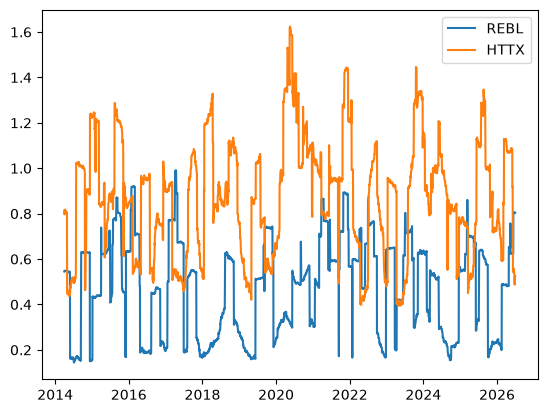

In [13]:
import matplotlib.pyplot as plt

for tk in ['REBL', 'HTTX']:
    sub = dv[dv['underlying'] == tk]
    plt.plot(sub['date'], sub['realized_vol_63d'], label=tk)
plt.legend()
plt.show()

Ni `REBL` ni `HTTX` muestran una deriva sostenida al alza o a la baja en 12 años, oscilan dentro de una banda estable.

In [14]:
dv_wide = dv.pivot(index='date', columns='underlying', values='realized_vol_63d')
dv_wide.head()

underlying,BSKR,CLNE,CORL,DRC,HTTX,JEDI,KYBR,MNDO,NABO,POBK,REBL,SITH,TECH,WOOK
date,,,,,,,,,,,,,,
2014-04-01,0.279154,0.137364,0.287269,0.305809,0.814416,0.125299,0.194111,0.363142,0.100739,0.337390,0.545894,0.274425,0.282766,0.267460
2014-04-02,0.278861,0.134646,0.285751,0.305588,0.800353,0.126348,0.186989,0.367584,0.099352,0.334682,0.546407,0.273967,0.276692,0.267728
2014-04-03,0.279286,0.137185,0.283533,0.311296,0.800380,0.126161,0.188895,0.367568,0.099855,0.348529,0.546205,0.273921,0.275871,0.267769
2014-04-04,0.280056,0.135644,0.281417,0.311039,0.797183,0.126143,0.187141,0.336099,0.099846,0.350344,0.545601,0.271726,0.268379,0.266409
2014-04-07,0.276618,0.134904,0.279998,0.307719,0.806554,0.125885,0.195557,0.334863,0.100517,0.348005,0.545676,0.273097,0.266193,0.266616


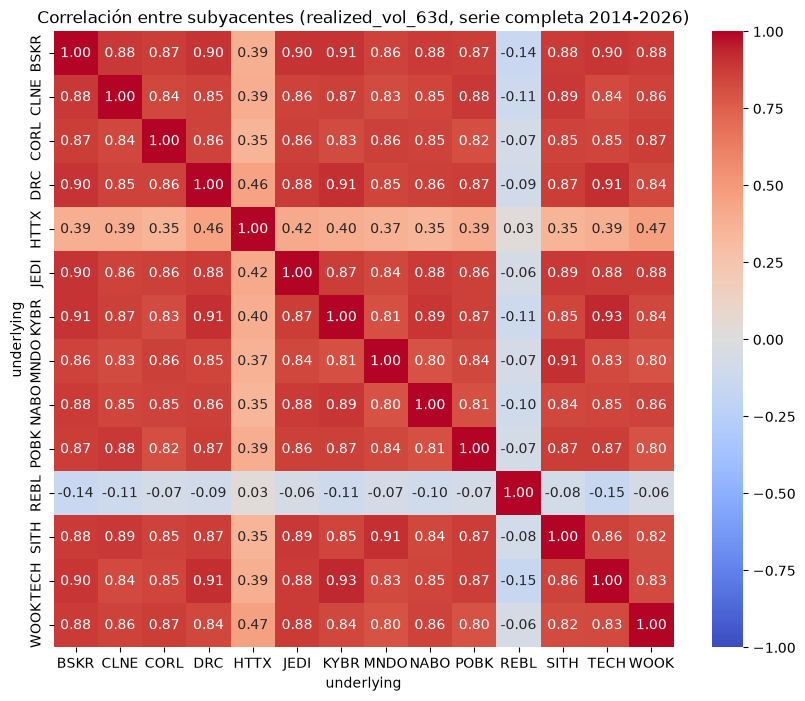

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(dv_wide.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre subyacentes (realized_vol_63d, serie completa 2014-2026)')
plt.show()

Doce de los catorce subyacentes (todos menos `HTTX` y `REBL`) muestran correlaciones entre sí en el rango 0.80-0.93, sistematicamente altas. Hay un factor de mercado compartido que domina el movimiento de la gran mayoría de subyacentes simulados.
- **Limitación:** Para cualquier cesta compuesta solo por activos de este bloque, la correlación va a ser sistemáticamente alta.

`REBL` y `HTTX` tienen esntre ellos una correlación baja (0.03).

`REBL` muestra correlación negativa con los doce subyacentes del bloque común.

In [16]:
dv.groupby('underlying')['realized_vol_63d'].nunique()

underlying
BSKR    3196
CLNE    3196
CORL    3196
DRC     3196
HTTX    3196
JEDI    3196
KYBR    3196
MNDO    3196
NABO    3196
POBK    3196
REBL    3196
SITH    3196
TECH    3196
WOOK    3196
Name: realized_vol_63d, dtype: int64

No hay valores repetidos en ninguna serie, es decir no hay periodos con el mismo valor sostenido.

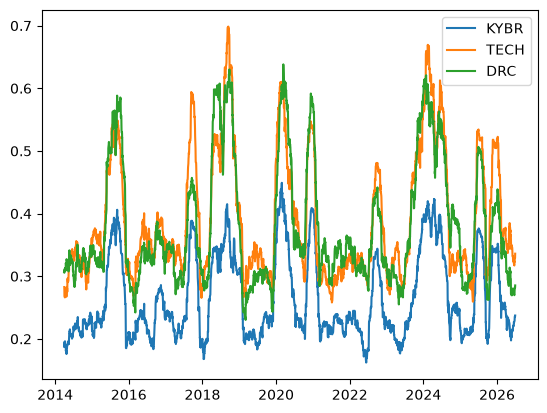

In [17]:
for tk in ['KYBR', 'TECH', 'DRC']:
    sub = dv[dv['underlying'] == tk]
    plt.plot(sub['date'], sub['realized_vol_63d'], label=tk)
plt.legend()
plt.show()

`KYBR`, `TECH` y `DRC` son precisamente tres d elos pares con correlación más alta. El gráfico lo confirma a simple vista, los tres picos y valles ocurren prácticamente en el mismo momento. Solo percibimos pequeñas diferencias de amplitud entre ellos.

In [18]:
dv.groupby('underlying')['realized_vol_63d'].apply(lambda s: s.autocorr(lag=1))

underlying
BSKR    0.997234
CLNE    0.997595
CORL    0.997012
DRC     0.997279
HTTX    0.982101
JEDI    0.996817
KYBR    0.996667
MNDO    0.997552
NABO    0.996797
POBK    0.997191
REBL    0.978325
SITH    0.997018
TECH    0.997111
WOOK    0.997243
Name: realized_vol_63d, dtype: float64

La autocorrelación de lag-1 enta entre 0.978 y 0.998 en los 14 subyacentes, es decir, el valor de `realized_vol_63d` de un día es casi indistinguible del día anterior para todos los subyacentes. Esto se había hipotetizado por la construcción de media movil de 63 días de la volatilidad realizada.
- **Limitación:** Cualquier correlación calculada directamente sobre esta serie va a estar inflada por esta redundancia interna.

Un detalle interesante es que `HTTX` y `REBL` presentan las dos autocorrelaciones más bajas, 0.982 y 0.978. Los dos mismos subyacentes que destacaban por diferenciarse del resto en la matriz de correlación. Esto tine sentido porque tambien son los que mostraban mayor variabilidad relativa.